#  Week 2 — Exploratory Data Analysis (EDA)



---
## Step 1 — Import Libraries & Load Cleaned Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('../dashboard/charts', exist_ok=True)

df = pd.read_csv('../data/hotel_bookings_cleaned.csv', parse_dates=['arrival_date'])

MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print(f"Data loaded: {df.shape[0]:,} rows | {df.shape[1]} columns")
print(f"Cancellation rate : {df['is_canceled'].mean()*100:.1f}%")
print(f"Date range        : {df['arrival_date'].min().date()} to {df['arrival_date'].max().date()}")

Data loaded: 10,000 rows | 41 columns
Cancellation rate : 40.0%
Date range        : 2016-01-01 to 2019-12-28


---
## Chart 1 — Overall Cancellation Rate (Pie Chart)



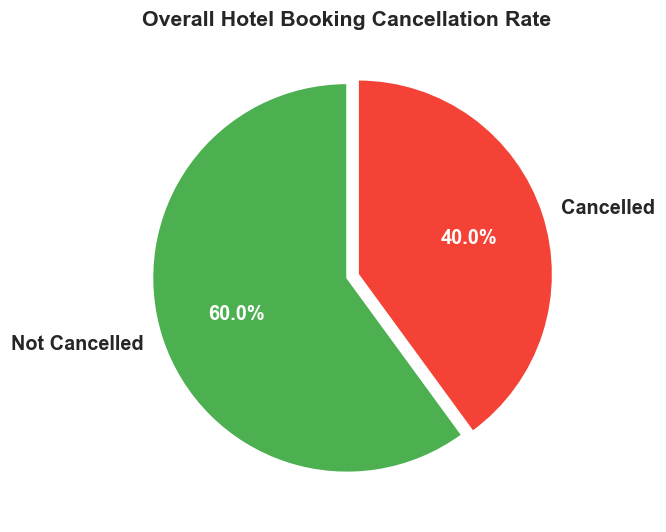

Cancelled     : 3,996 bookings (40.0%)
Not Cancelled : 6,004 bookings (60.0%)

Business Insight: ~40% cancellation rate is very high — strong retention action needed!


In [2]:
fig, ax = plt.subplots(figsize=(7,5))

vals    = df['is_canceled'].value_counts()
labels  = ['Not Cancelled', 'Cancelled']
colors  = ['#4CAF50', '#F44336']
explode = [0, 0.06]

wedges, texts, autotexts = ax.pie(
    vals, labels=labels, colors=colors, autopct='%1.1f%%',
    startangle=90, explode=explode,
    textprops={'fontsize':13,'fontweight':'bold'})

for at in autotexts:
    at.set_color('white')
    at.set_fontsize(13)

ax.set_title('Overall Hotel Booking Cancellation Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/charts/01_cancellation_pie.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Cancelled     : {vals[1]:,} bookings ({vals[1]/len(df)*100:.1f}%)")
print(f"Not Cancelled : {vals[0]:,} bookings ({vals[0]/len(df)*100:.1f}%)")
print()
print("Business Insight: ~40% cancellation rate is very high — strong retention action needed!")

---
## Chart 2 — Monthly Booking Volume (Line Chart)



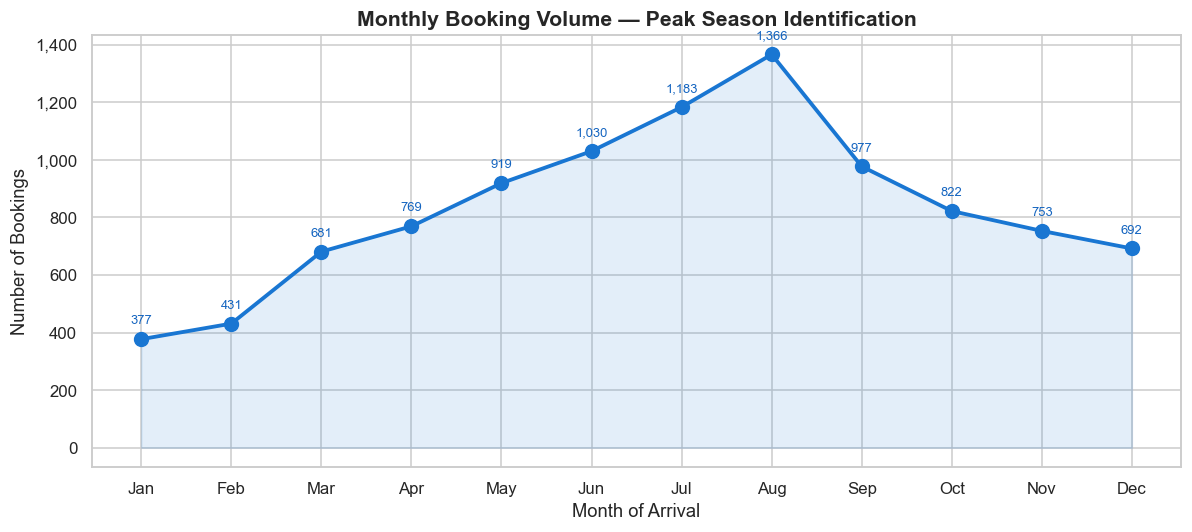

Peak month   : Aug (1,366 bookings)
Lowest month : Jan  (377 bookings)

Business Insight: Apply highest prices in peak month — demand supports premium rates!


In [3]:
monthly = df.groupby('arrival_month_num').size().reset_index(name='bookings')
monthly['month'] = monthly['arrival_month_num'].apply(lambda x: MONTHS[x-1])

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(monthly['month'], monthly['bookings'],
        marker='o', linewidth=2.5, color='#1976D2', markersize=9)
ax.fill_between(monthly['month'], monthly['bookings'], alpha=0.12, color='#1976D2')

for _, row in monthly.iterrows():
    ax.annotate(f"{int(row['bookings']):,}",
        (MONTHS[int(row['arrival_month_num'])-1], row['bookings']),
        textcoords='offset points', xytext=(0,10),
        ha='center', fontsize=8.5, color='#1565C0')

ax.set_title('Monthly Booking Volume — Peak Season Identification', fontsize=14, fontweight='bold')
ax.set_xlabel('Month of Arrival', fontsize=12)
ax.set_ylabel('Number of Bookings', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../dashboard/charts/02_monthly_booking_volume.png', dpi=130, bbox_inches='tight')
plt.show()

peak = monthly.loc[monthly['bookings'].idxmax()]
low  = monthly.loc[monthly['bookings'].idxmin()]
print(f"Peak month   : {peak['month']} ({int(peak['bookings']):,} bookings)")
print(f"Lowest month : {low['month']}  ({int(low['bookings']):,} bookings)")
print()
print("Business Insight: Apply highest prices in peak month — demand supports premium rates!")

---
## Chart 3 — Cancellation Rate by Hotel Type (Bar Chart)



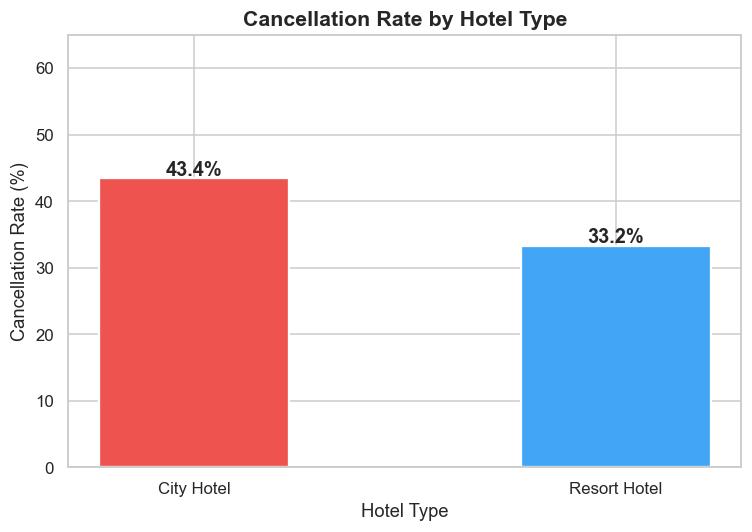

City Hotel: 43.4% cancellation rate
Resort Hotel: 33.2% cancellation rate

Business Insight: City Hotels need stronger retention programs than Resort Hotels!


In [4]:
hc = df.groupby('hotel')['is_canceled'].mean().reset_index()
hc['pct'] = (hc['is_canceled']*100).round(1)

fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(hc['hotel'], hc['pct'], color=['#EF5350','#42A5F5'],
              width=0.45, edgecolor='white', linewidth=1.5)

for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{bar.get_height():.1f}%", ha='center', fontsize=13, fontweight='bold')

ax.set_title('Cancellation Rate by Hotel Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Cancellation Rate (%)', fontsize=12)
ax.set_xlabel('Hotel Type', fontsize=12)
ax.set_ylim(0,65)
plt.tight_layout()
plt.savefig('../dashboard/charts/03_cancellation_hotel_type.png', dpi=130, bbox_inches='tight')
plt.show()

for _, row in hc.iterrows():
    print(f"{row['hotel']}: {row['pct']}% cancellation rate")
print()
print("Business Insight: City Hotels need stronger retention programs than Resort Hotels!")

---
## Chart 4 — Room Price (ADR) vs Cancellation (Box Plot)



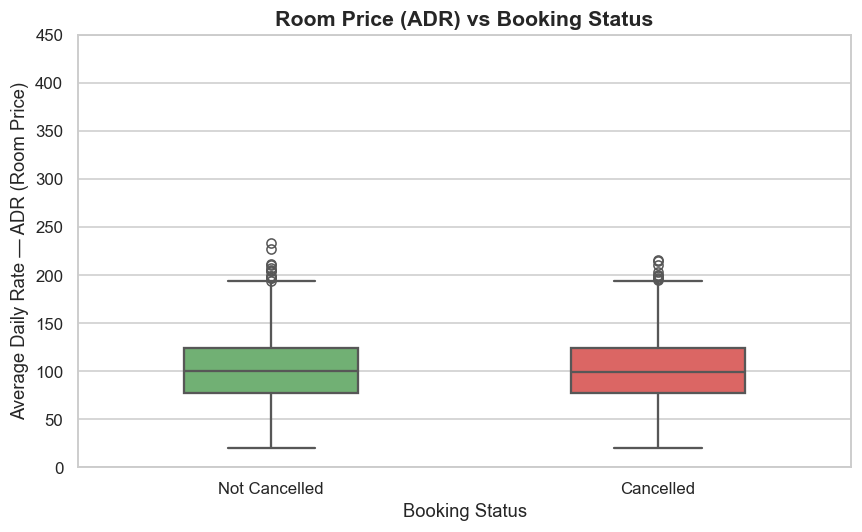

Avg ADR — Not Cancelled : 101.43
Avg ADR — Cancelled     : 101.47

Business Insight: Higher-priced bookings cancel slightly more. Combine flexible pricing with deposit policy!


In [5]:
df['Status'] = df['is_canceled'].map({0:'Not Cancelled', 1:'Cancelled'})

fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x='Status', y='adr',
            palette={'Not Cancelled':'#66BB6A','Cancelled':'#EF5350'},
            width=0.45, linewidth=1.5, ax=ax)

ax.set_title('Room Price (ADR) vs Booking Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Booking Status', fontsize=12)
ax.set_ylabel('Average Daily Rate — ADR (Room Price)', fontsize=12)
ax.set_ylim(0,450)
plt.tight_layout()
plt.savefig('../dashboard/charts/04_adr_vs_cancellation.png', dpi=130, bbox_inches='tight')
plt.show()

k = df[df['is_canceled']==0]['adr'].mean()
c = df[df['is_canceled']==1]['adr'].mean()
print(f"Avg ADR — Not Cancelled : {k:.2f}")
print(f"Avg ADR — Cancelled     : {c:.2f}")
print()
print("Business Insight: Higher-priced bookings cancel slightly more. Combine flexible pricing with deposit policy!")

---
## Chart 5 — Lead Time Distribution (Histogram)



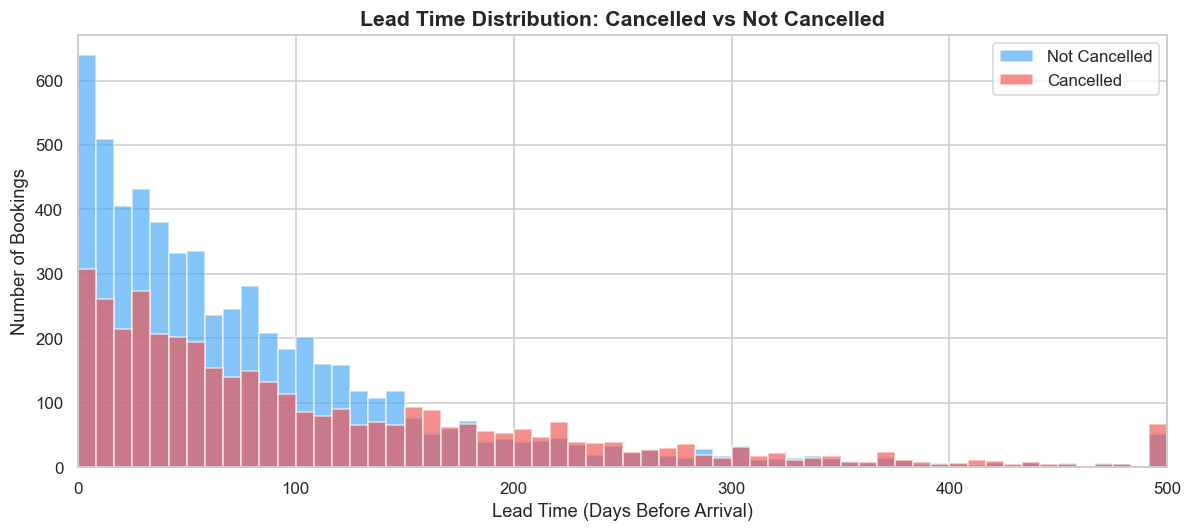

Avg lead time — Not Cancelled : 86 days
Avg lead time — Cancelled     : 115 days

Business Insight: Long lead-time = high cancellation risk. Send reminder emails at Day-60 and Day-30!


In [6]:
fig, ax = plt.subplots(figsize=(11,5))

df[df['is_canceled']==0]['lead_time'].plot(
    kind='hist', bins=60, alpha=0.65, label='Not Cancelled', color='#42A5F5', ax=ax)
df[df['is_canceled']==1]['lead_time'].plot(
    kind='hist', bins=60, alpha=0.65, label='Cancelled', color='#EF5350', ax=ax)

ax.set_title('Lead Time Distribution: Cancelled vs Not Cancelled', fontsize=14, fontweight='bold')
ax.set_xlabel('Lead Time (Days Before Arrival)', fontsize=12)
ax.set_ylabel('Number of Bookings', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(0,500)
plt.tight_layout()
plt.savefig('../dashboard/charts/05_lead_time_histogram.png', dpi=130, bbox_inches='tight')
plt.show()

lt_kept   = df[df['is_canceled']==0]['lead_time'].mean()
lt_cancel = df[df['is_canceled']==1]['lead_time'].mean()
print(f"Avg lead time — Not Cancelled : {lt_kept:.0f} days")
print(f"Avg lead time — Cancelled     : {lt_cancel:.0f} days")
print()
print("Business Insight: Long lead-time = high cancellation risk. Send reminder emails at Day-60 and Day-30!")

---
## Chart 6 — Average Daily Rate by Month (Seasonal Pricing Trend)



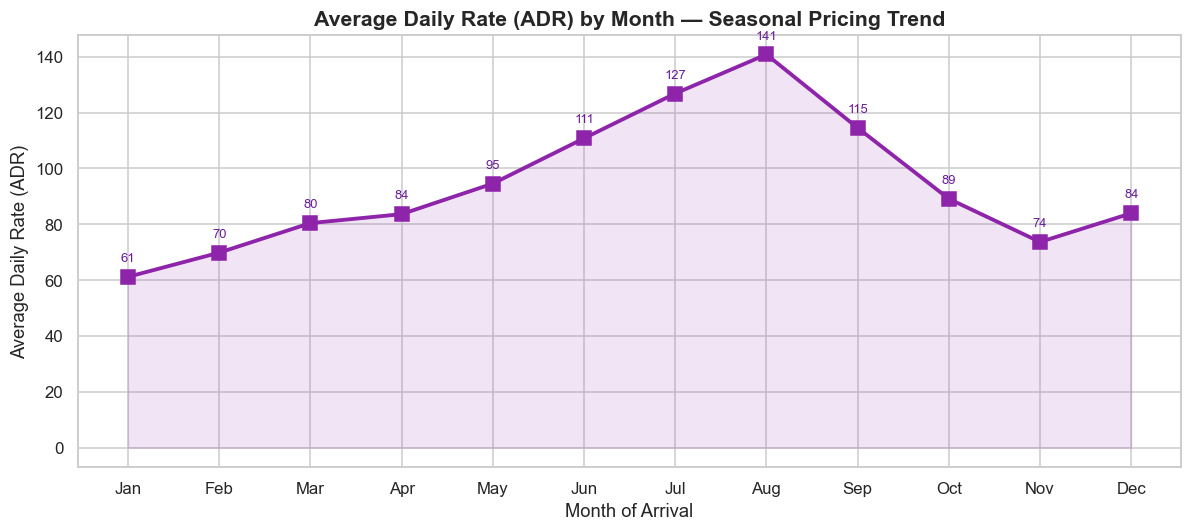

Highest ADR month : Aug (140.83)
Lowest  ADR month : Jan  (61.18)

Business Insight: Raise prices 20-30% in summer — peak demand allows premium pricing!


In [7]:
m_adr = df.groupby('arrival_month_num')['adr'].mean().reset_index()
m_adr['month'] = m_adr['arrival_month_num'].apply(lambda x: MONTHS[x-1])

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(m_adr['month'], m_adr['adr'],
        marker='s', linewidth=2.5, color='#8E24AA', markersize=9)
ax.fill_between(m_adr['month'], m_adr['adr'], alpha=0.12, color='#8E24AA')

for _, row in m_adr.iterrows():
    ax.annotate(f"{row['adr']:.0f}",
        (MONTHS[int(row['arrival_month_num'])-1], row['adr']),
        textcoords='offset points', xytext=(0,10),
        ha='center', fontsize=8.5, color='#6A1B9A')

ax.set_title('Average Daily Rate (ADR) by Month — Seasonal Pricing Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month of Arrival', fontsize=12)
ax.set_ylabel('Average Daily Rate (ADR)', fontsize=12)
plt.tight_layout()
plt.savefig('../dashboard/charts/06_seasonal_adr_trend.png', dpi=130, bbox_inches='tight')
plt.show()

peak_m = m_adr.loc[m_adr['adr'].idxmax()]
low_m  = m_adr.loc[m_adr['adr'].idxmin()]
print(f"Highest ADR month : {peak_m['month']} ({peak_m['adr']:.2f})")
print(f"Lowest  ADR month : {low_m['month']}  ({low_m['adr']:.2f})")
print()
print("Business Insight: Raise prices 20-30% in summer — peak demand allows premium pricing!")

---
## Chart 7 — Customer Segment Distribution (Bar Chart)


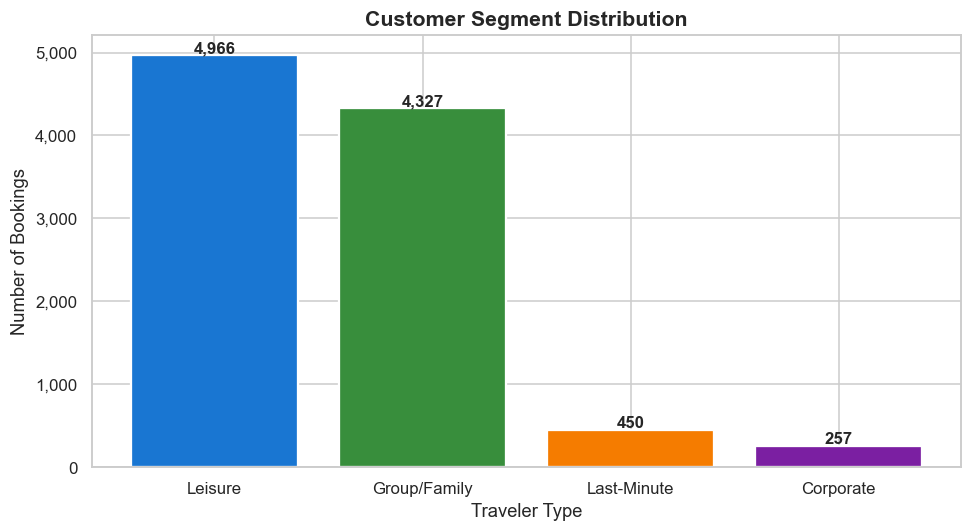

Leisure        : 4,966 bookings (49.7%) | Cancel rate: 40.6%
Group/Family   : 4,327 bookings (43.3%) | Cancel rate: 40.1%
Last-Minute    : 450 bookings (4.5%) | Cancel rate: 31.8%
Corporate      : 257 bookings (2.6%) | Cancel rate: 38.5%


In [8]:
seg = df['traveler_type'].value_counts().reset_index()
seg.columns = ['Segment','Count']

colors = ['#1976D2','#388E3C','#F57C00','#7B1FA2']
fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(seg['Segment'], seg['Count'], color=colors, edgecolor='white', linewidth=1.5)

for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            f"{int(bar.get_height()):,}", ha='center', fontsize=11, fontweight='bold')

ax.set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Traveler Type', fontsize=12)
ax.set_ylabel('Number of Bookings', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../dashboard/charts/07_customer_segments.png', dpi=130, bbox_inches='tight')
plt.show()

for _, row in seg.iterrows():
    pct = row['Count']/len(df)*100
    cr  = df[df['traveler_type']==row['Segment']]['is_canceled'].mean()*100
    print(f"{row['Segment']:<15}: {row['Count']:,} bookings ({pct:.1f}%) | Cancel rate: {cr:.1f}%")

---
## Chart 8 — Feature Correlation Heatmap



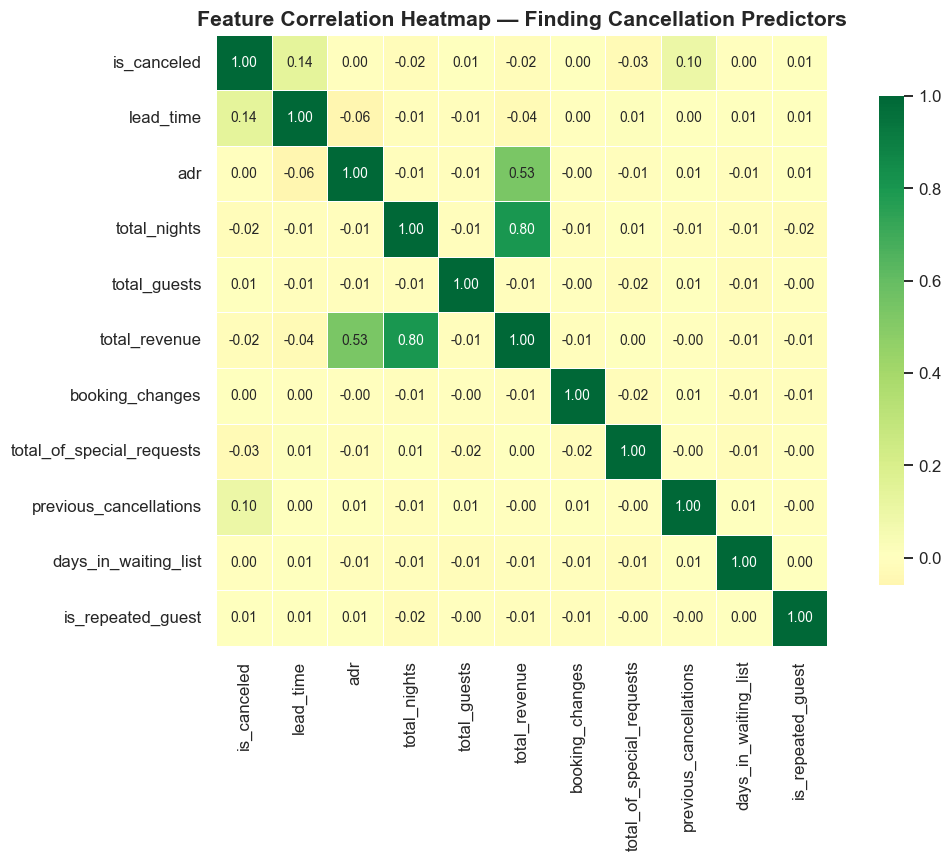

Top features correlated with cancellation:
  lead_time                          : 0.140
  previous_cancellations             : 0.099
  total_of_special_requests          : 0.034
  total_nights                       : 0.021
  total_revenue                      : 0.016
  is_repeated_guest                  : 0.011
  total_guests                       : 0.006
  booking_changes                    : 0.004
  days_in_waiting_list               : 0.001
  adr                                : 0.001


In [9]:
num_cols = ['is_canceled','lead_time','adr','total_nights','total_guests',
            'total_revenue','booking_changes','total_of_special_requests',
            'previous_cancellations','days_in_waiting_list','is_repeated_guest']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size':9}, square=True, cbar_kws={'shrink':0.8})

ax.set_title('Feature Correlation Heatmap — Finding Cancellation Predictors',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/charts/08_correlation_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

top = corr['is_canceled'].drop('is_canceled').abs().sort_values(ascending=False)
print("Top features correlated with cancellation:")
for feat, val in top.items():
    print(f"  {feat:<35}: {val:.3f}")

---
## Chart 9 — Cancellation Rate by Deposit Type (Bar Chart)
 


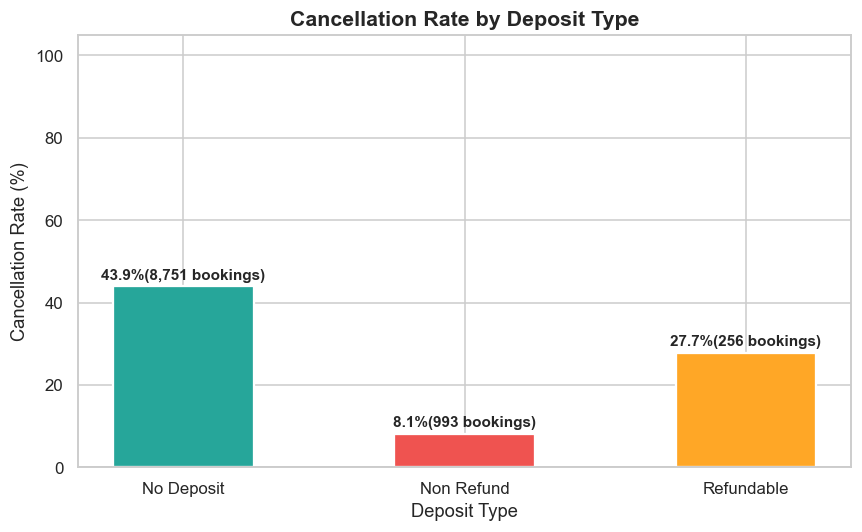

No Deposit     : 43.9% cancellation rate
Non Refund     : 8.1% cancellation rate
Refundable     : 27.7% cancellation rate

MAJOR Business Insight: Non-Refundable bookings barely ever cancel!
Hotel should incentivise non-refundable rates with 10-15% discount.


In [13]:
dep = (df.groupby('deposit_type')['is_canceled'].mean()*100).round(1)
dep_cnt = df.groupby('deposit_type').size()

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(dep.index, dep.values, color=['#26A69A','#EF5350','#FFA726'],
              edgecolor='white', linewidth=1.5, width=0.5)

for bar, (dtype, cnt) in zip(bars, dep_cnt.items()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f"{bar.get_height():.1f}%({cnt:,} bookings)",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Cancellation Rate by Deposit Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Cancellation Rate (%)', fontsize=12)
ax.set_xlabel('Deposit Type', fontsize=12)
ax.set_ylim(0,105)
plt.tight_layout()
plt.savefig('../dashboard/charts/09_cancellation_by_deposit.png', dpi=130, bbox_inches='tight')
plt.show()

for dtype, pct in dep.items():
    print(f"{dtype:<15}: {pct:.1f}% cancellation rate")
print()
print("MAJOR Business Insight: Non-Refundable bookings barely ever cancel!")
print("Hotel should incentivise non-refundable rates with 10-15% discount.")